peak times (s): [0.4028712 2.2157916]
inhibition time(s): 1.8129203999999999


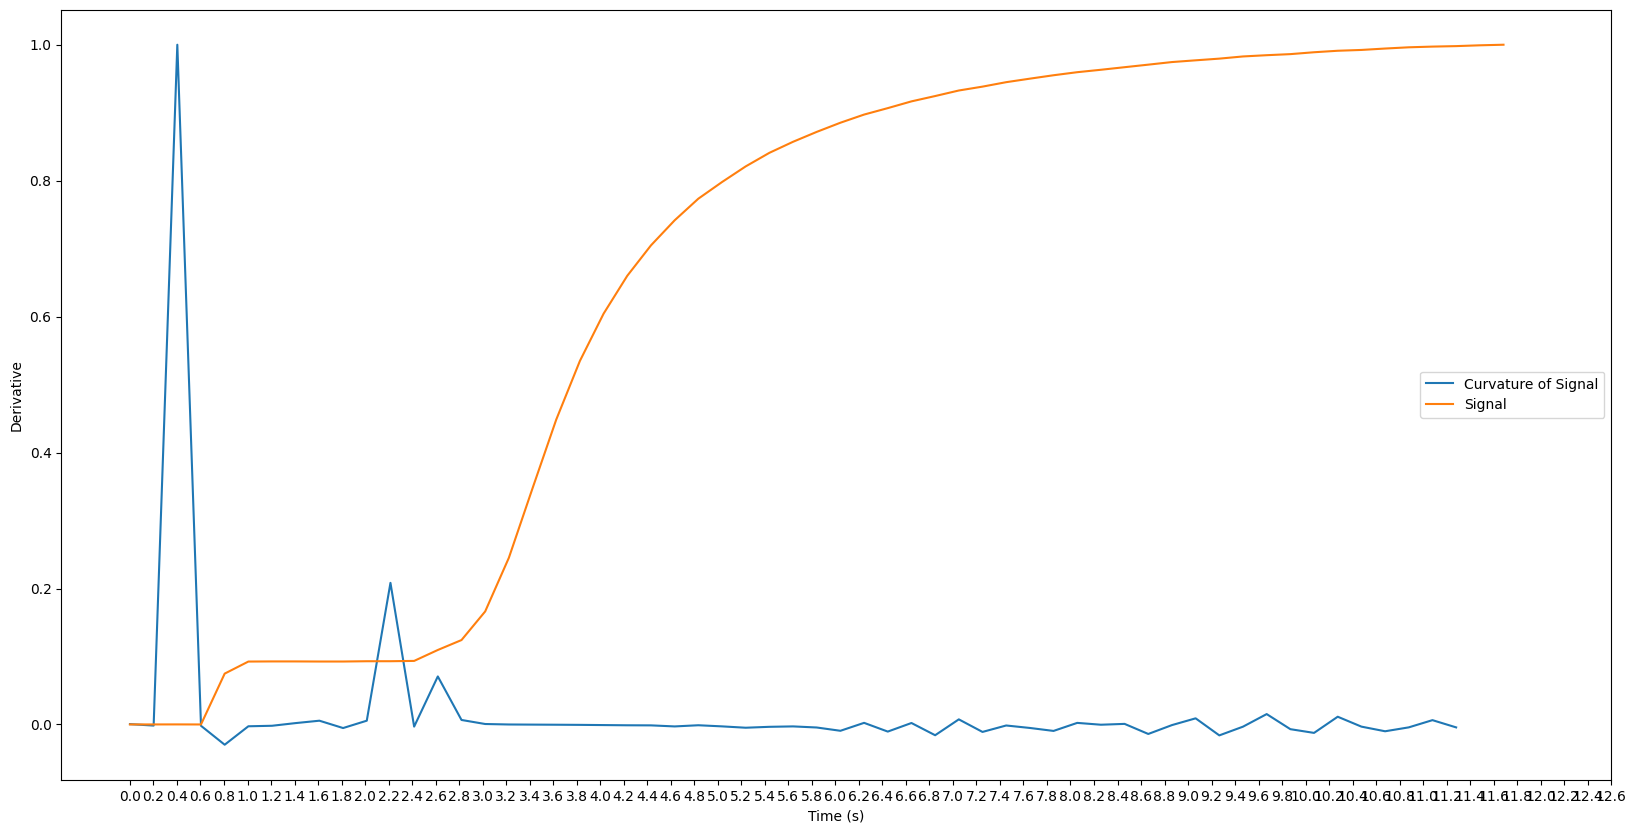

In [ ]:
from time import time

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
from scipy.signal import find_peaks

file_path='.\\circles_TEMPO_10,15,20,25mW_0,1,5mM\\1mM TEMPO\\15mW 1mM TEMPO\\intensity_data.csv'
df=pd.read_csv(file_path)
df.dropna(inplace=True)
#print(df.head(5))
time1=df['15mW_1_mM_TEMPO_T1_Time_s'].values
signal1=df['15mW_1_mM_TEMPO_T1_Intensity'].values

t30_1=next((time1[i] for i in range(len(signal1)) if signal1[i] >= 0.3), None)
t90_1=next((time1[i] for i in range(len(signal1)) if signal1[i] >= 0.9), None)

d1=np.diff(signal1)
d2=np.diff(d1)
#plt.plot(time1[:-1], d1, label='First Derivative of Signal')
#plt.plot(time1[:-2], d2, label='Second Derivative of Signal')

plt.figure(figsize=(20,10))
k=d2/((1+d1[:-1]**2)**(3/2))
plt.plot(time1[:-2], k/k.max(), label='Curvature of Signal')
plt.plot(time1,signal1/signal1.max(), label='Signal')
plt.xlabel('Time (s)')
plt.xticks(np.arange(0, max(time1)+1, 0.2))
plt.ylabel('Derivative')
plt.legend()
#plt.show()
#peak_i=next(i for i in range(len(k)) if k[i] == max(k))
#print(f"Peak curvature at time: {time1[peak_i+2]} seconds")
dt=time1[1]-time1[0]
peaks,_=find_peaks(k, height=0.5)
top2 = peaks[np.argsort(k[peaks])[-2:]]
top2 = np.sort(top2)  # chronological order
print("peak times (s):", top2 * dt)
print('inhibition time(s):',(top2[1]-top2[0])*dt)